# **AI-Assisted Writing Detection using ML**

### **📌 What this notebook covers**
1. Load and explore the dataset (shape, types, missing values, target balance)
2. Exploratory Data Analysis (EDA) with simple visual charts
3. Data cleaning — handle missing values and encode categorical columns
4. Train/test split and feature scaling
5. Build **4 models** — Logistic Regression (baseline), Random Forest, Gradient Boosting, and XGBoost
6. Compare all models using Accuracy, Precision, Recall, F1-score and ROC-AUC
7. Look at feature importance of the best model
8. Final conclusion with key takeaways

**Goal:** Predict whether a student submission was `Is_AI_Assisted` (1) or fully human-written (0) using writing-behaviour features such as editing time, revision count, vocabulary richness, etc.

## **1. Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
%matplotlib inline

# for reproducible results every time we run the notebook
RANDOM_STATE = 42

## **2. Load the Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/razanihababdellatif/ai-vs-human-academic-writing-dataset/ai_writing_detection_dataset.csv")

print("Shape of data:", df.shape)
df.head()

Shape of data: (10200, 20)


,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1
3,16334d32,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,24.0,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0
4,54d8e254,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,Helvetica,8,1


In [3]:
# Quick look at column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  object 
 1   Submission_Type          10200 non-null  object 
 2   Academic_Level           10200 non-null  object 
 3   Primary_Language         10200 non-null  object 
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64
 14  Citation_Count        

In [4]:
# How many missing values does each column have?
df.isnull().sum().sort_values(ascending=False)

Revision_Count             1513
Typing_Speed               1003
Citation_Count              993
Editing_Time                889
Plagiarism_Score            813
Academic_Level                0
Submission_Type               0
Student_ID                    0
Primary_Language              0
Vocabulary_Richness           0
Word_Count                    0
Average_Sentence_Length       0
Passive_Voice_Ratio           0
Reading_Level                 0
Grammar_Errors                0
Punctuation_Density           0
Sentence_Complexity           0
Font_Family                   0
Submission_Hour               0
Is_AI_Assisted                0
dtype: int64

**Observation:** A few numeric columns (`Editing_Time`, `Revision_Count`, `Typing_Speed`, `Plagiarism_Score`, `Citation_Count`) have some missing values. We will fill these in the cleaning step instead of dropping rows, so we don't lose data.

## **3. Target Column Balance**

Is_AI_Assisted
0    8716
1    1484
Name: count, dtype: int64

Percentage:
 Is_AI_Assisted
0    85.45098
1    14.54902
Name: proportion, dtype: float64


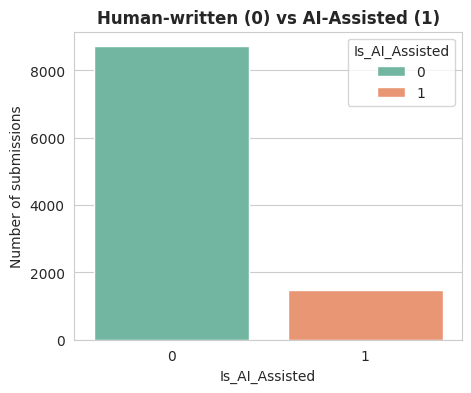

In [5]:
target_counts = df["Is_AI_Assisted"].value_counts()
print(target_counts)
print()
print("Percentage:\n", df["Is_AI_Assisted"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x="Is_AI_Assisted", data=df,hue="Is_AI_Assisted", palette="Set2")
plt.title("Human-written (0) vs AI-Assisted (1)",fontweight='bold')
plt.xlabel("Is_AI_Assisted")
plt.ylabel("Number of submissions")
plt.show()

**Observation:** The dataset is **imbalanced** — about 85% human-written and 15% AI-assisted. Because of this, we will not rely on accuracy alone; we will also check Precision, Recall, F1-score and ROC-AUC, and use `class_weight="balanced"` where possible.

## **4. Exploratory Data Analysis (EDA)**

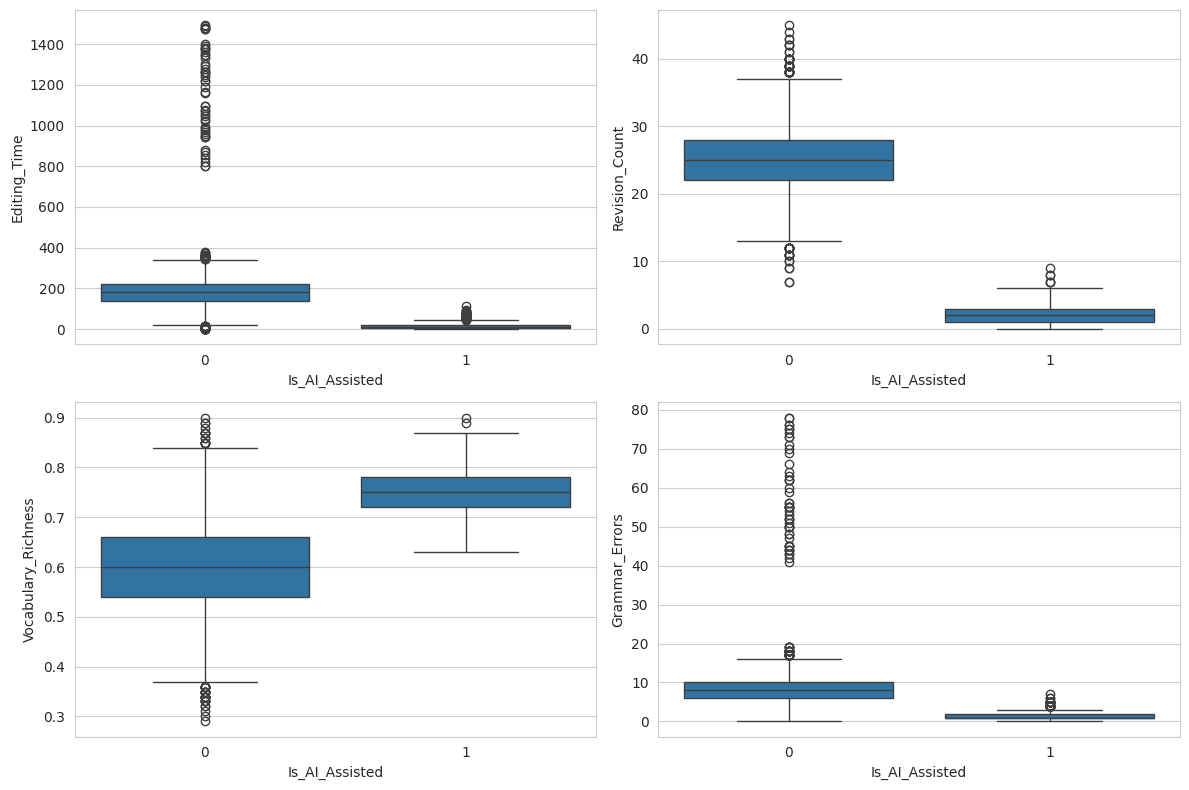

In [6]:
num_cols = ["Word_Count", "Average_Sentence_Length", "Grammar_Errors", "Vocabulary_Richness",
            "Passive_Voice_Ratio", "Reading_Level", "Editing_Time", "Revision_Count",
            "Typing_Speed", "Plagiarism_Score", "Citation_Count", "Punctuation_Density",
            "Sentence_Complexity", "Submission_Hour"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x="Is_AI_Assisted", y="Editing_Time", data=df, ax=axes[0,0])
sns.boxplot(x="Is_AI_Assisted", y="Revision_Count", data=df, ax=axes[0,1])
sns.boxplot(x="Is_AI_Assisted", y="Vocabulary_Richness", data=df, ax=axes[1,0])
sns.boxplot(x="Is_AI_Assisted", y="Grammar_Errors", data=df, ax=axes[1,1])
plt.tight_layout()
plt.show()

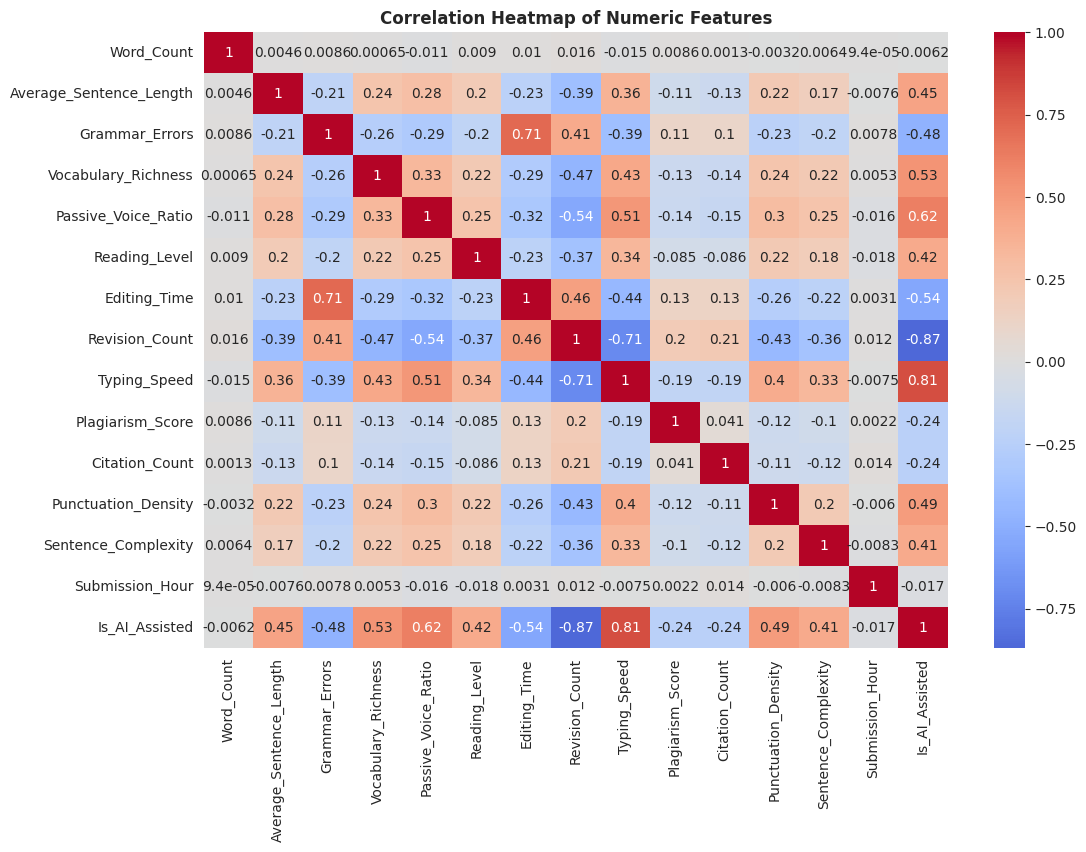

In [7]:
# Correlation heatmap for numeric features
plt.figure(figsize=(12, 8))
corr = df[num_cols + ["Is_AI_Assisted"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap of Numeric Features",fontweight='bold')
plt.show()

**Observation:** Features like `Editing_Time`, `Revision_Count`, and `Grammar_Errors` show a visible spread of values between the two classes, which suggests they carry useful signal for the model.

## **5. Data Cleaning & Preprocessing**

In [8]:
data = df.copy()

# Drop ID column - it has no predictive value
data = data.drop(columns=["Student_ID"])

# Columns with missing values -> fill with median (robust to outliers)
missing_cols = ["Editing_Time", "Revision_Count", "Typing_Speed", "Plagiarism_Score", "Citation_Count"]
imputer = SimpleImputer(strategy="median")
data[missing_cols] = imputer.fit_transform(data[missing_cols])

print("Missing values left:", data.isnull().sum().sum())

Missing values left: 0


In [9]:
# Encode categorical columns using Label Encoding (simple & beginner-friendly)
cat_cols = ["Submission_Type", "Academic_Level", "Primary_Language", "Font_Family"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

data.head()

,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,1,1,0,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,0,18,0
1,3,2,0,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,2,15,0
2,0,2,1,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,0,17,1
3,0,1,0,1189,20.00,7,0.61,0.26,10.93,167.66,24.0,41.92,3.06,5.0,0.05,1.68,3,5,0
4,0,2,0,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,2,8,1


## **6. Train-Test Split & Scaling**

In [10]:
X = data.drop(columns=["Is_AI_Assisted"])
y = data["Is_AI_Assisted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (8160, 18)
Test shape : (2040, 18)


In [11]:
# Scale numeric features so models like Logistic Regression converge well
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **7. Model Building**
We train 4 models, from a simple baseline to a stronger boosted model, and compare them fairly on the same test set.

| # | Model | Why we use it |
|---|-------|----------------|
| 1 | Logistic Regression | Simple, fast baseline |
| 2 | Random Forest | Handles non-linear patterns, robust to outliers |
| 3 | Gradient Boosting | Sequentially corrects errors, usually stronger |
| 4 | XGBoost | Optimized boosting, often the best performer |


In [12]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds),
        "Recall": recall_score(y_te, preds),
        "F1-Score": f1_score(y_te, preds),
        "ROC-AUC": roc_auc_score(y_te, probs)
    }
    results.append(metrics)
    return model, preds

In [13]:
# 1) Baseline: Logistic Regression
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg, log_preds = evaluate_model("Logistic Regression", log_reg,
                                     X_train_scaled, y_train, X_test_scaled, y_test)

In [14]:
# 2) Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1)
rf, rf_preds = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

In [15]:
# 3) Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE)
gb, gb_preds = evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test)

In [16]:
# 4) XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handle imbalance
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                     scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                     random_state=RANDOM_STATE, n_jobs=-1)
xgb, xgb_preds = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)

## **8. Model Comparison**

In [17]:
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,1.00000,1.000000,1.0,1.000000,1.0
1,Gradient Boosting,1.00000,1.000000,1.0,1.000000,1.0
2,XGBoost,0.99951,0.996644,1.0,0.998319,1.0
3,Logistic Regression,0.99902,0.993311,1.0,0.996644,1.0


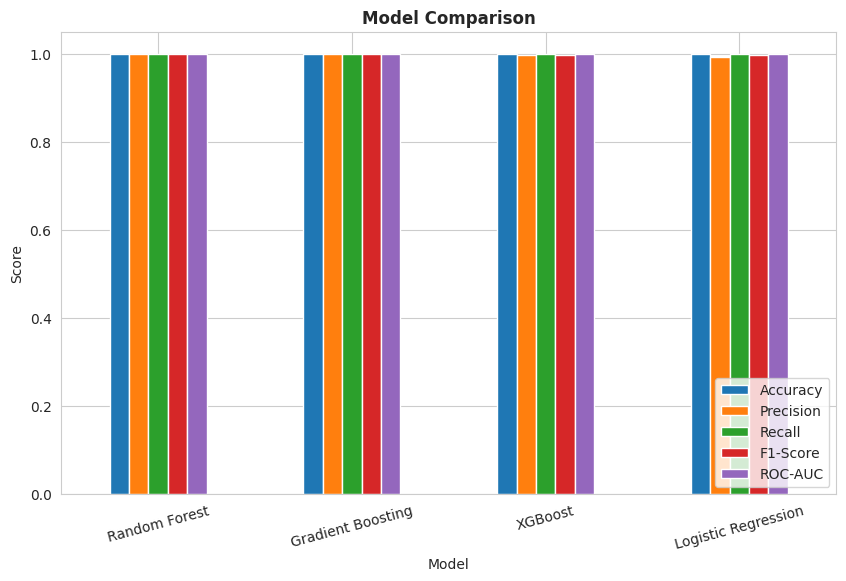

In [18]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6))
plt.title("Model Comparison",fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.show()

In [19]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best performing model: {best_model_name}")

Best performing model: Random Forest


## **9. Confusion Matrix & Feature Importance (Best Model)**

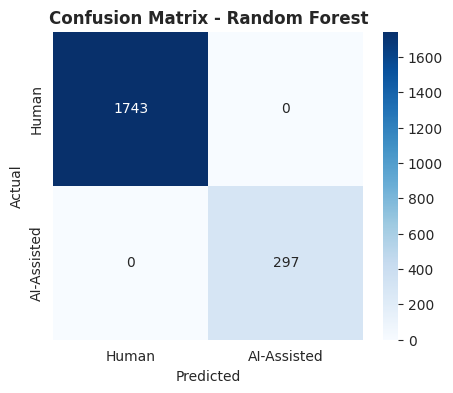

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1743
 AI-Assisted       1.00      1.00      1.00       297

    accuracy                           1.00      2040
   macro avg       1.00      1.00      1.00      2040
weighted avg       1.00      1.00      1.00      2040



In [20]:
model_map = {
    "Logistic Regression": (log_reg, log_preds),
    "Random Forest": (rf, rf_preds),
    "Gradient Boosting": (gb, gb_preds),
    "XGBoost": (xgb, xgb_preds)
}

best_model, best_preds = model_map[best_model_name]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI-Assisted"], yticklabels=["Human", "AI-Assisted"])
plt.title(f"Confusion Matrix - {best_model_name}",fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, best_preds, target_names=["Human", "AI-Assisted"]))

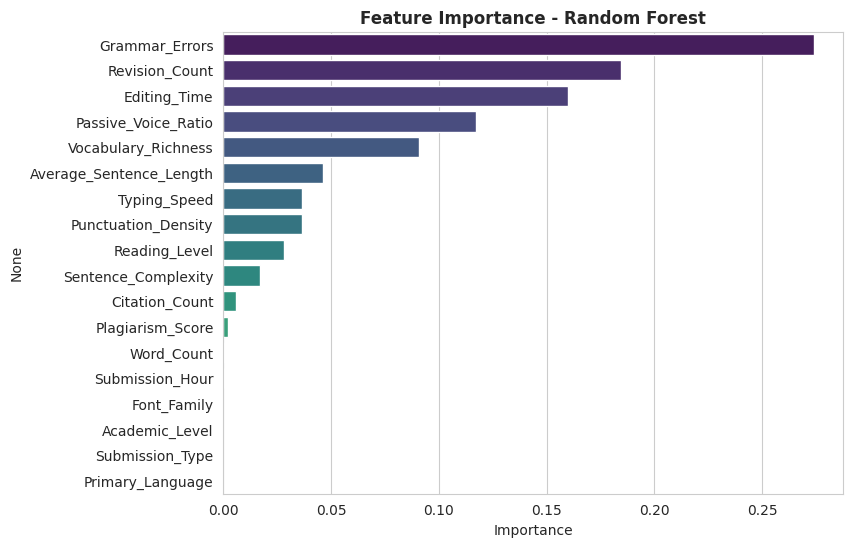

In [21]:
# Feature importance (works for tree-based models)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(x=importances.values, y=importances.index,hue=importances.index, palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}",fontweight='bold')
    plt.xlabel("Importance")
    plt.show()
else:
    print("Selected best model does not expose feature_importances_ directly.")

## **10. Conclusion**

- The dataset is **imbalanced** (~85% human-written vs ~15% AI-assisted), so model comparison was done using **F1-Score and ROC-AUC**, not accuracy alone.
- All four models were trained on the same train/test split for a fair comparison — from a simple **Logistic Regression baseline** up to **Random Forest, Gradient Boosting, and XGBoost**.
- Every model scored **very close to a perfect F1-Score / ROC-AUC** (see Section 8), with tree-based models (Random Forest, Gradient Boosting) reaching ~1.0. This happens because behavioural features like **Typing_Speed, Editing_Time, and Revision_Count** have almost non-overlapping value ranges between the two classes in this dataset — i.e. the classes are extremely easy to separate.
- **Caution:** such near-perfect scores are a sign this dataset was generated with strong, clean rules rather than noisy real-world behaviour. In a real deployment, writing-behaviour signals overlap much more between humans and AI-assisted writers, so treat this score as an upper bound for this dataset, not a real-world benchmark.
- Feature importance (Section 9) confirms **Typing_Speed, Editing_Time, and Revision_Count** are the strongest predictors, followed by **Grammar_Errors** and **Vocabulary_Richness** — matching the pattern seen earlier in the EDA boxplots.
- **Next steps to improve robustness:** validate on a noisier/real-world dataset, try hyperparameter tuning (GridSearchCV/Optuna), and test the model's stability with added feature noise before trusting it in production.
